In [1]:
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import polars as pl

from src.config.constants import Product
from src.processing.dataset_spec import DatasetSpec
from src.research.trader_activity import generate_inventory_df
from src.processing.trades import TradesDataProcessor, TradesDataset


VELVETFRUIT_EXTRACT = Product.VELVETFRUIT_EXTRACT
VEV_OPTIONS_PREF: Final[str] = "VEV_"
ROUND: Final[int] = 4
DAY: Final[int] = 1

DATASET: Final[DatasetSpec] = DatasetSpec(ROUND, DAY)
TRADES_CSV_FILE: Final[Path] = DATASET.trades()
RAW_UNDERLYING_TRADES_DATA: Final[TradesDataProcessor] = TradesDataset(
    TRADES_CSV_FILE
).for_product(VELVETFRUIT_EXTRACT)
RAW_OPTIONS_TRADES_DATA: Final[TradesDataProcessor] = TradesDataset(
    TRADES_CSV_FILE
).for_product("VEV_")


underlying_trades_data: Final[pl.DataFrame] = RAW_UNDERLYING_TRADES_DATA.clean(
    keep_sides=True
).build()
options_trades_data: pl.DataFrame = RAW_OPTIONS_TRADES_DATA.clean(
    keep_sides=True
).build()

In [2]:
underlying_trades_data

timestamp,buyer,seller,price,quantity
i64,str,str,f64,i64
6100,"""Mark 55""","""Mark 01""",5255.0,3
9400,"""Mark 55""","""Mark 49""",5244.0,8
10400,"""Mark 67""","""Mark 49""",5240.0,12
14300,"""Mark 55""","""Mark 01""",5238.0,6
14800,"""Mark 01""","""Mark 55""",5232.0,6
…,…,…,…,…
985600,"""Mark 67""","""Mark 49""",5252.0,14
986300,"""Mark 67""","""Mark 22""",5254.0,10
988000,"""Mark 55""","""Mark 01""",5256.0,4


In [3]:
options_trades_data

timestamp,buyer,seller,price,quantity
i64,str,str,f64,i64
4500,"""Mark 01""","""Mark 22""",18.0,2
4500,"""Mark 01""","""Mark 22""",8.0,2
4500,"""Mark 01""","""Mark 22""",0.0,2
4500,"""Mark 01""","""Mark 22""",0.0,2
5300,"""Mark 38""","""Mark 14""",1264.0,2
…,…,…,…,…
990300,"""Mark 01""","""Mark 22""",15.0,5
990300,"""Mark 01""","""Mark 22""",0.0,5
990300,"""Mark 01""","""Mark 22""",0.0,5


In [4]:
unique_buyers_underlying = underlying_trades_data["buyer"].unique().to_list()
unique_sellers_underlying = underlying_trades_data["seller"].unique().to_list()

print("Underlying buyers:", sorted(unique_buyers_underlying))
print("Underlying sellers:", sorted(unique_sellers_underlying))

Underlying buyers: ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 49', 'Mark 55', 'Mark 67']
Underlying sellers: ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 49', 'Mark 55']


In [5]:
unique_buyers_options = options_trades_data["buyer"].unique().to_list()
unique_sellers_options = options_trades_data["seller"].unique().to_list()

print("Options buyers:", sorted(unique_buyers_options))
print("Options sellers:", sorted(unique_sellers_options))

Options buyers: ['Mark 01', 'Mark 14', 'Mark 38']
Options sellers: ['Mark 14', 'Mark 22', 'Mark 38']


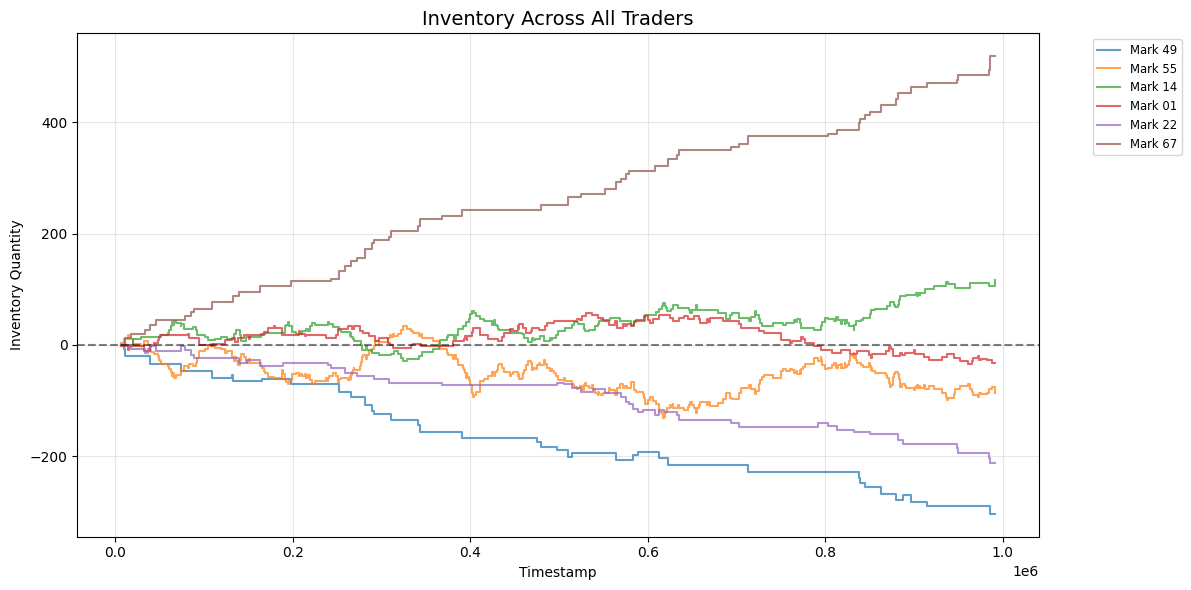

In [6]:
unique_traders = unique_buyers_underlying

plt.figure(figsize=(12, 6))

# 1. Iterate through each trader name
for trader in unique_traders:
    # 2. Use your existing function to get that trader's specific DF
    trader_df = generate_inventory_df(trader, underlying_trades_data)

    # 3. Plot them on the same axis (Matplotlib handles the colors automatically)
    plt.step(
        trader_df["timestamp"],
        trader_df["inventory"],
        where="post",
        label=trader,
        alpha=0.7,
        linewidth=1.5,
    )

# 4. Final plot touches
plt.title("Inventory Across All Traders", fontsize=14)
plt.xlabel("Timestamp")
plt.ylabel("Inventory Quantity")
plt.axhline(0, color="black", alpha=0.5, linestyle="--")  # The 'zero' line
plt.grid(True, alpha=0.3)

# Move the legend outside if you have many traders
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")

plt.tight_layout()
plt.show()